In [1]:
pip install pandas numpy matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [5]:
matches = pd.read_csv('matches .csv')
deliveries = pd.read_csv('deliveries.csv')

print(f'Matches dataset:    {matches.shape[0]} rows × {matches.shape[1]} columns')
print(f'Deliveries dataset: {deliveries.shape[0]} rows × {deliveries.shape[1]} columns')

Matches dataset:    1095 rows × 20 columns
Deliveries dataset: 260920 rows × 17 columns


In [6]:
# ── Matches overview ──────────────────────────────────────────────────────────
print('=== MATCHES — First look ===')
print(matches.head(3).to_string())
print('\nData types:')
print(matches.dtypes)

=== MATCHES — First look ===
       id   season        city        date match_type player_of_match                                       venue                        team1                  team2                  toss_winner toss_decision                 winner   result  result_margin  target_runs  target_overs super_over method    umpire1         umpire2
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum                       M Chinnaswamy Stadium  Royal Challengers Bangalore  Kolkata Knight Riders  Royal Challengers Bangalore         field  Kolkata Knight Riders     runs          140.0        223.0          20.0          N    NaN  Asad Rauf     RE Koertzen
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab    Chennai Super Kings          Chennai Super Kings           bat    Chennai Super Kings     runs           33.0        241.0          20.0          N    NaN  MR Benson    

In [7]:
# ── Deliveries overview ───────────────────────────────────────────────────────
print('=== DELIVERIES — First look ===')
print(deliveries.head(3).to_string())
print('\nData types:')
print(deliveries.dtypes)

=== DELIVERIES — First look ===
   match_id  inning           batting_team                 bowling_team  over  ball       batter   bowler  non_striker  batsman_runs  extra_runs  total_runs extras_type  is_wicket player_dismissed dismissal_kind fielder
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0     1   SC Ganguly  P Kumar  BB McCullum             0           1           1     legbyes          0              NaN            NaN     NaN
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0     2  BB McCullum  P Kumar   SC Ganguly             0           0           0         NaN          0              NaN            NaN     NaN
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0     3  BB McCullum  P Kumar   SC Ganguly             0           1           1       wides          0              NaN            NaN     NaN

Data types:
match_id             int64
inning               int64
batting_team        o

In [8]:
# ── Missing values ────────────────────────────────────────────────────────────
print('=== MISSING VALUES ===')
print('\nMatches:')
print(matches.isnull().sum()[matches.isnull().sum() > 0])

print('\nDeliveries:')
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])

=== MISSING VALUES ===

Matches:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

Deliveries:
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [9]:
# Remove Super Over rows (not regular match play)
if 'super_over' in deliveries.columns:
    deliveries = deliveries[deliveries['super_over'] == 'N']
    print(f'Deliveries after removing super overs: {deliveries.shape[0]}')

# Drop matches with no result (abandonments, no result)
matches_clean = matches[matches['result'] != 'no result'].copy()
print(f'Matches after removing no-result games: {matches_clean.shape[0]}')

# Standardise team name inconsistencies (common in IPL datasets)
team_rename = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Kings XI Punjab': 'Punjab Kings'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    if col in matches_clean.columns:
        matches_clean[col] = matches_clean[col].replace(team_rename)

print('\nTeam names standardised ✅')
print(sorted(matches_clean['team1'].unique()))

Matches after removing no-result games: 1090

Team names standardised ✅
['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [12]:
#Q1. Does winning toss give a competitive advantage ?

In [10]:
# Did the toss winner also win the match?
matches_clean['toss_match_win'] = matches_clean['toss_winner'] == matches_clean['winner']

toss_win_rate = matches_clean['toss_match_win'].mean() * 100
print(f'Overall toss-to-match win rate: {toss_win_rate:.1f}%')

# Break it down by toss decision
toss_decision_win = (
    matches_clean.groupby('toss_decision')['toss_match_win']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'win_rate', 'count': 'matches'})
)
toss_decision_win['win_rate'] = (toss_decision_win['win_rate'] * 100).round(1)
print('\nWin rate by toss decision:')
print(toss_decision_win)

Overall toss-to-match win rate: 50.8%

Win rate by toss decision:
               win_rate  matches
toss_decision                   
bat                45.4      390
field              53.9      700


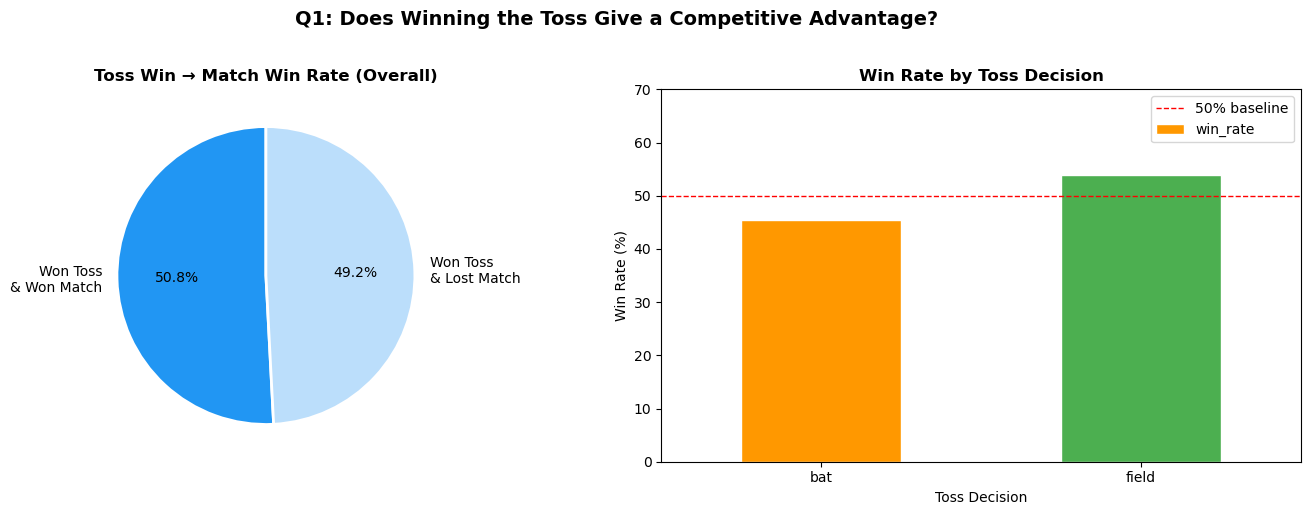

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Overall toss advantage
labels = ['Won Toss\n& Won Match', 'Won Toss\n& Lost Match']
sizes = [toss_win_rate, 100 - toss_win_rate]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['#2196F3', '#BBDEFB'], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Toss Win → Match Win Rate (Overall)', fontweight='bold')

# Chart 2 — By toss decision
toss_decision_win['win_rate'].plot(kind='bar', ax=axes[1],
                                    color=['#FF9800', '#4CAF50'], edgecolor='white', width=0.5)
axes[1].set_title('Win Rate by Toss Decision', fontweight='bold')
axes[1].set_xlabel('Toss Decision')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 70)
axes[1].axhline(50, color='red', linestyle='--', linewidth=1, label='50% baseline')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Q1: Does Winning the Toss Give a Competitive Advantage?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1_toss_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
#Insight

In [15]:
#Q2. How has Run Rate Evolved Across Seasons ?

In [16]:
# Merge deliveries with match season info
match_season = matches_clean[['id', 'season']].rename(columns={'id': 'match_id'})
deliveries_season = deliveries.merge(match_season, on='match_id', how='inner')

# Calculate total runs and balls per match, then run rate
match_stats = (
    deliveries_season.groupby(['match_id', 'season'])
    .agg(
        total_runs=('total_runs', 'sum'),
        total_balls=('ball', 'count')
    )
    .reset_index()
)
match_stats['run_rate'] = (match_stats['total_runs'] / match_stats['total_balls']) * 6

season_avg = match_stats.groupby('season')['run_rate'].mean().reset_index()
print(season_avg)

     season  run_rate
0   2007/08  7.957732
1      2009  7.227063
2   2009/10  7.795673
3      2011  7.440602
4      2012  7.573468
5      2013  7.470888
6      2014  7.922345
7      2015  8.102815
8      2016  8.000792
9      2017  8.088623
10     2018  8.362224
11     2019  8.110948
12  2020/21  7.979684
13     2021  7.731167
14     2022  8.137379
15     2023  8.632043
16     2024  9.086288


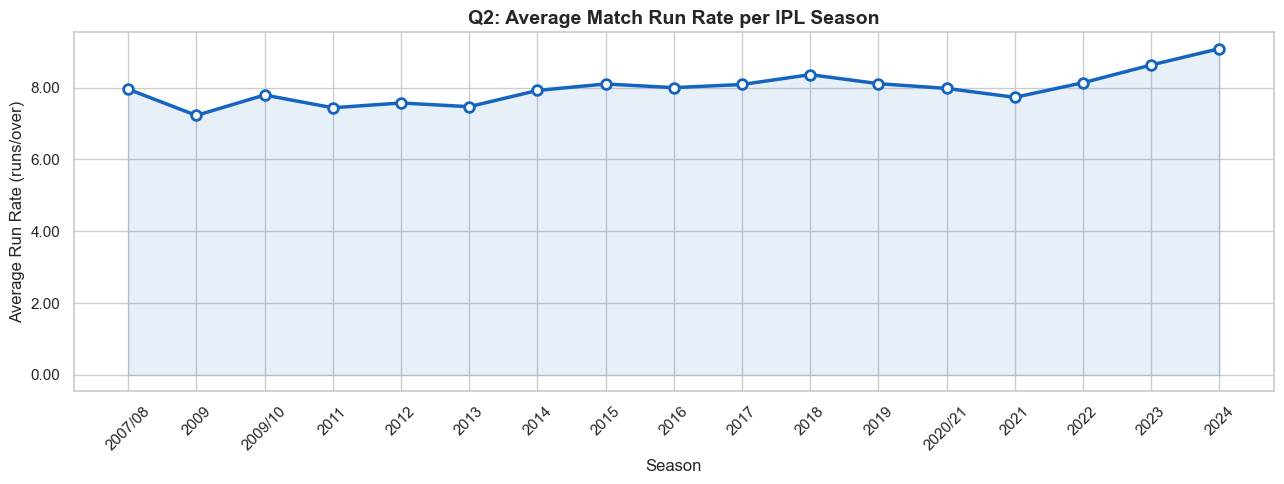

In [20]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(season_avg['season'].astype(str), season_avg['run_rate'],
        marker='o', linewidth=2.5, color='#1565C0', markersize=7, markerfacecolor='white',
        markeredgewidth=2)

ax.fill_between(season_avg['season'].astype(str), season_avg['run_rate'],
                alpha=0.1, color='#1565C0')

ax.set_title('Q2: Average Match Run Rate per IPL Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Average Run Rate (runs/over)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('q2_run_rate_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
#Insight 

In [22]:
#Q3. Which Bowlers Are Most Economical in Death Overs(16-20) ?

In [23]:
# Filter to death overs only
death_overs = deliveries_season[deliveries_season['over'].between(15, 19)]  # 0-indexed: overs 16-20

# Minimum 200 balls bowled in death overs (filters out occasional bowlers)
MIN_BALLS = 200

death_stats = (
    death_overs.groupby('bowler')
    .agg(
        runs_conceded=('total_runs', 'sum'),
        balls_bowled=('ball', 'count')
    )
    .reset_index()
)
death_stats = death_stats[death_stats['balls_bowled'] >= MIN_BALLS].copy()
death_stats['economy'] = (death_stats['runs_conceded'] / death_stats['balls_bowled']) * 6
death_stats = death_stats.sort_values('economy').head(12)

print(f'Top 12 most economical death-over bowlers (min {MIN_BALLS} balls):')
print(death_stats[['bowler', 'balls_bowled', 'runs_conceded', 'economy']].to_string(index=False))

Top 12 most economical death-over bowlers (min 200 balls):
         bowler  balls_bowled  runs_conceded  economy
   DE Bollinger           242            297 7.363636
      SP Narine          1044           1287 7.396552
     SL Malinga          1174           1526 7.798978
       R Ashwin           620            816 7.896774
    Rashid Khan           524            701 8.026718
 M Muralitharan           284            380 8.028169
       DW Steyn           662            895 8.111782
Harbhajan Singh           282            382 8.127660
      JJ Bumrah          1298           1767 8.167951
    M Pathirana           266            363 8.187970
     WD Parnell           243            337 8.320988
  Kuldeep Yadav           287            400 8.362369


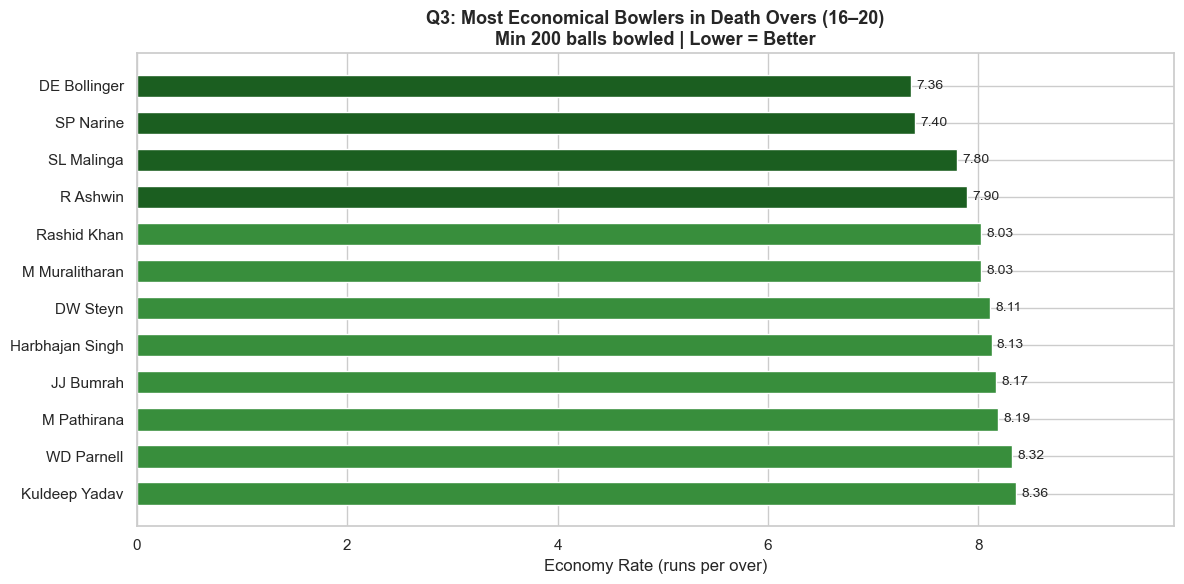

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1B5E20' if e < 8 else '#388E3C' if e < 9 else '#66BB6A'
          for e in death_stats['economy']]

bars = ax.barh(death_stats['bowler'], death_stats['economy'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, death_stats['economy']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)

ax.set_title('Q3: Most Economical Bowlers in Death Overs (16–20)\n'
             f'Min {MIN_BALLS} balls bowled | Lower = Better',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Economy Rate (runs per over)')
ax.invert_yaxis()
ax.set_xlim(0, death_stats['economy'].max() + 1.5)

plt.tight_layout()
plt.savefig('q3_death_over_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
#Insight 

In [26]:
#Q4. Which Venues Favour Batsmen vs Bowlers ?

In [27]:
# First innings runs only
first_innings = deliveries_season[deliveries_season['inning'] == 1]

first_innings_totals = (
    first_innings.groupby('match_id')['total_runs']
    .sum()
    .reset_index()
    .rename(columns={'total_runs': 'first_innings_score'})
)

# Join with venue info
venue_scores = first_innings_totals.merge(
    matches_clean[['id', 'venue']].rename(columns={'id': 'match_id'}),
    on='match_id'
)

# Min 15 matches at venue for reliability
MIN_MATCHES = 15
venue_avg = (
    venue_scores.groupby('venue')
    .agg(avg_score=('first_innings_score', 'mean'), match_count=('match_id', 'count'))
    .reset_index()
)
venue_avg = venue_avg[venue_avg['match_count'] >= MIN_MATCHES]
venue_avg = venue_avg.sort_values('avg_score', ascending=False)

# Shorten long venue names for display
venue_avg['venue_short'] = venue_avg['venue'].str.split(',').str[0].str[:35]

print(venue_avg[['venue_short', 'avg_score', 'match_count']].head(10).to_string(index=False))

                        venue_short  avg_score  match_count
               Arun Jaitley Stadium 199.062500           16
                       Eden Gardens 195.625000           16
                  Brabourne Stadium 177.411765           17
                   Wankhede Stadium 177.111111           45
              Narendra Modi Stadium 175.750000           24
         Dr DY Patil Sports Academy 170.700000           20
              M Chinnaswamy Stadium 167.253968           63
Maharashtra Cricket Association Sta 166.409091           22
                   Wankhede Stadium 166.027397           73
             MA Chidambaram Stadium 166.020833           48


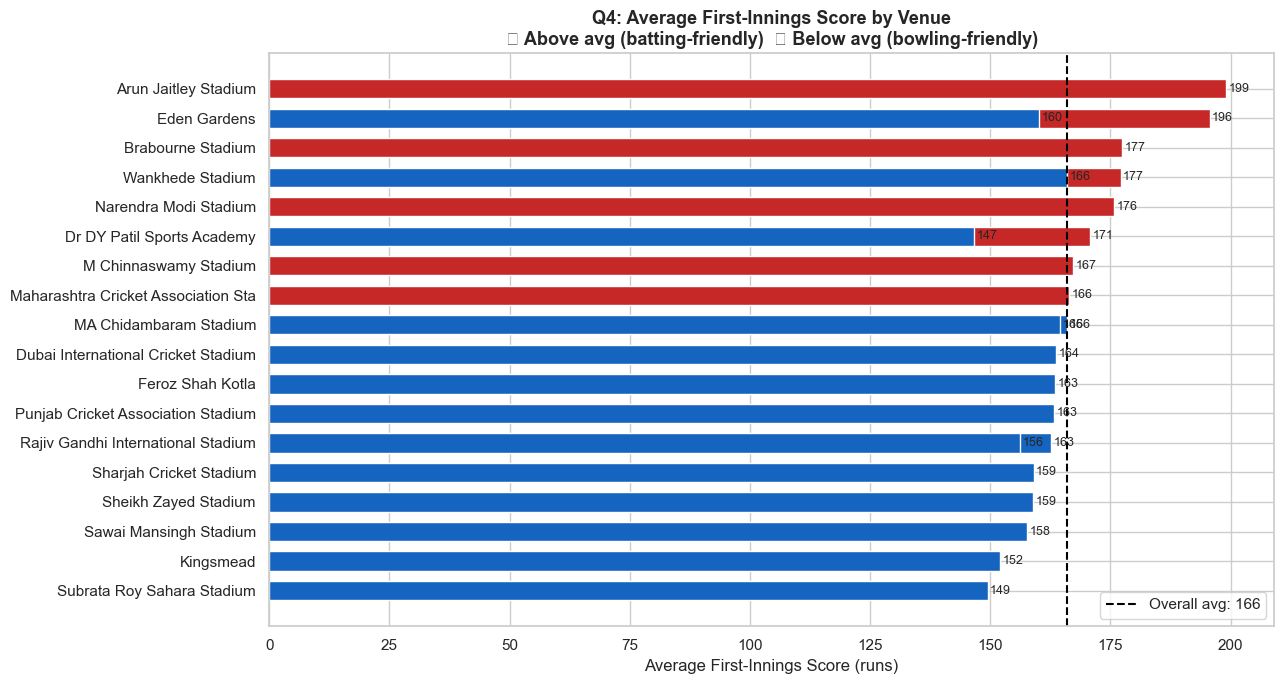

In [29]:
overall_avg = venue_avg['avg_score'].mean()

fig, ax = plt.subplots(figsize=(13, 7))

bar_colors = ['#C62828' if s > overall_avg else '#1565C0'
              for s in venue_avg['avg_score']]

bars = ax.barh(venue_avg['venue_short'], venue_avg['avg_score'],
               color=bar_colors, edgecolor='white', height=0.65)

ax.axvline(overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {overall_avg:.0f}')

for bar, val in zip(bars, venue_avg['avg_score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=9)

ax.set_title('Q4: Average First-Innings Score by Venue\n'
             '🔴 Above avg (batting-friendly)  🔵 Below avg (bowling-friendly)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average First-Innings Score (runs)')
ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.savefig('q4_venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
#Insight 

In [31]:
#Q5. Top Run Scorers : Consistency vs Strike Rate

In [32]:
# Batsman career stats
batsman_stats = (
    deliveries.groupby('batter')
    .agg(
        total_runs=('batsman_runs', 'sum'),
        balls_faced=('ball', 'count'),
        innings=('match_id', 'nunique')
    )
    .reset_index()
)
batsman_stats['strike_rate'] = (batsman_stats['total_runs'] / batsman_stats['balls_faced']) * 100
batsman_stats['avg_per_innings'] = batsman_stats['total_runs'] / batsman_stats['innings']

# Top 20 by total runs
top20 = batsman_stats.nlargest(20, 'total_runs')
print(top20[['batter', 'total_runs', 'innings', 'strike_rate', 'avg_per_innings']]
      .round(1).to_string(index=False))

        batter  total_runs  innings  strike_rate  avg_per_innings
       V Kohli        8014      244        128.5             32.8
      S Dhawan        6769      221        123.5             30.6
     RG Sharma        6630      251        127.9             26.4
     DA Warner        6567      184        135.4             35.7
      SK Raina        5536      200        132.5             27.7
      MS Dhoni        5243      228        132.8             23.0
AB de Villiers        5181      170        148.6             30.5
      CH Gayle        4997      141        142.1             35.4
    RV Uthappa        4954      197        126.2             25.1
    KD Karthik        4843      233        131.4             20.8
      KL Rahul        4689      122        131.1             38.4
     AM Rahane        4642      171        120.3             27.1
  F du Plessis        4571      138        133.1             33.1
     SV Samson        4419      162        135.1             27.3
     AT Ra

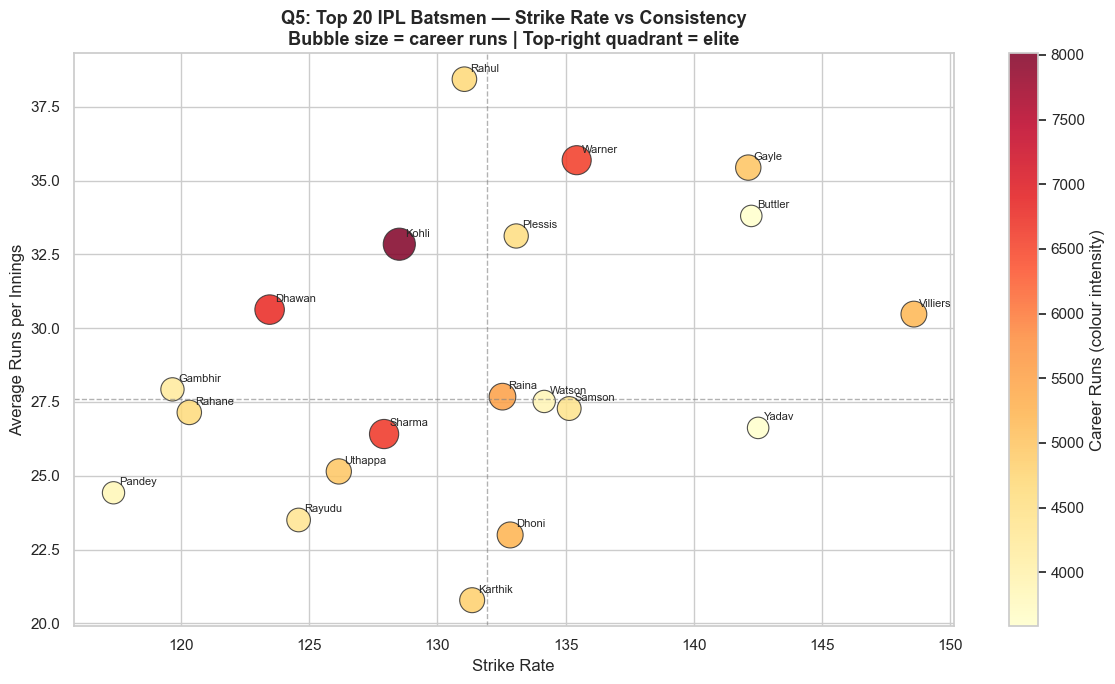

In [33]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    top20['strike_rate'],
    top20['avg_per_innings'],
    s=top20['total_runs'] / 15,      # bubble size = career runs
    c=top20['total_runs'],
    cmap='YlOrRd',
    alpha=0.85,
    edgecolors='#333',
    linewidths=0.8
)

# Label each bubble
for _, row in top20.iterrows():
    ax.annotate(row['batter'].split()[-1],  # last name only
                (row['strike_rate'], row['avg_per_innings']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

# Quadrant lines
ax.axvline(top20['strike_rate'].median(), color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(top20['avg_per_innings'].median(), color='grey', linestyle='--', linewidth=1, alpha=0.6)

plt.colorbar(scatter, label='Career Runs (colour intensity)')
ax.set_xlabel('Strike Rate')
ax.set_ylabel('Average Runs per Innings')
ax.set_title('Q5: Top 20 IPL Batsmen — Strike Rate vs Consistency\n'
             'Bubble size = career runs | Top-right quadrant = elite',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('q5_batsman_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Insight 